# K-Means Clustering on the F1 Dataset

**Aim:** Implement the K-Means Clustering algorithm using Python and analyze the formed clusters using suitable visualization techniques.

## What is K-Means Clustering?

K-Means is an **unsupervised machine-learning algorithm** that divides a dataset into a predefined number of groups called **clusters**. The core idea is to place *similar* data points in the same cluster and *dissimilar* points in different clusters. There is **no target variable** — the algorithm discovers the groups on its own.

**F1 version:** instead of customers, we cluster **driver-seasons**, and instead of Income vs. Spending we use two directly comparable performance metrics — **average grid position** and **average finishing position**. This gives the same kind of 2-D, easy-to-visualise clustering the lab demonstrates, but on the F1 data.

## How K-Means works (the 5 steps from the lab)

1. **Select K** — the number of clusters (chosen via the Elbow Method / Silhouette Score).
2. **Initialize centroids** — pick K points as initial cluster centers.
3. **Assign points** — each point goes to its nearest centroid (Euclidean distance).
4. **Recalculate centroids** — each centroid becomes the mean of its assigned points.
5. **Repeat** steps 3–4 until the centroids stop moving (convergence).

The algorithm minimises the **Within-Cluster Sum of Squares (WCSS)** — the total squared distance of points from their cluster centroid.

## Step 1 — Import required libraries

In [12]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

## Step 2 — Load the dataset

We load `f1.csv` (the export uses `\N` for missing values, so we tell pandas to treat that as `NaN`). We restrict to the **2004+ era** for consistent, modern records.

Because a single race is too noisy to cluster (one good race doesn't define a driver), we aggregate the data to **one row per driver-season** and compute two performance features:

- **`avg_grid`** — the driver's average starting (qualifying) position that season → measures car/driver *pace*.
- **`avg_finish`** — the driver's average finishing position that season → measures actual *results*.

This is the F1 equivalent of the retail lab's *Annual Income* and *Spending Score*.

In [13]:
CSV = "/content/f1.csv"

raw = pd.read_csv(CSV, na_values=["\\N"], low_memory=False)
raw = raw[raw["season"] >= 2004].copy()
raw["grid"] = raw["grid"].replace(0, np.nan)   # grid 0 = pit-lane start -> treat as missing

df = (raw.groupby(["driverId", "driver_name", "season"])
         .agg(races      = ("resultId", "size"),
              avg_grid   = ("grid", "mean"),
              avg_finish = ("positionOrder", "mean"),
              total_points = ("points", "sum"))
         .reset_index())

# keep only driver-seasons with a real sample of races
df = df[df["races"] >= 5].dropna(subset=["avg_grid", "avg_finish"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print(df.head())
print(df.info())

Dataset shape: (464, 7)
   driverId     driver_name  season  races  avg_grid  avg_finish  total_points
0         1  Lewis Hamilton    2007     17  2.588235    3.941176         109.0
1         1  Lewis Hamilton    2008     18  3.888889    5.222222          98.0
2         1  Lewis Hamilton    2009     17  9.176471    9.705882          49.0
3         1  Lewis Hamilton    2010     19  5.157895    6.421053         240.0
4         1  Lewis Hamilton    2011     19  3.578947    6.736842         227.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   driverId      464 non-null    int64  
 1   driver_name   464 non-null    object 
 2   season        464 non-null    int64  
 3   races         464 non-null    int64  
 4   avg_grid      464 non-null    float64
 5   avg_finish    464 non-null    float64
 6   total_points  464 non-null    float64
dtypes: flo

## Step 3 — Select features and visualize the original data

We cluster on the two features `avg_grid` and `avg_finish`. Before clustering, we plot the raw data as a scatter plot — this helps us see whether natural groups of driver-seasons already appear.

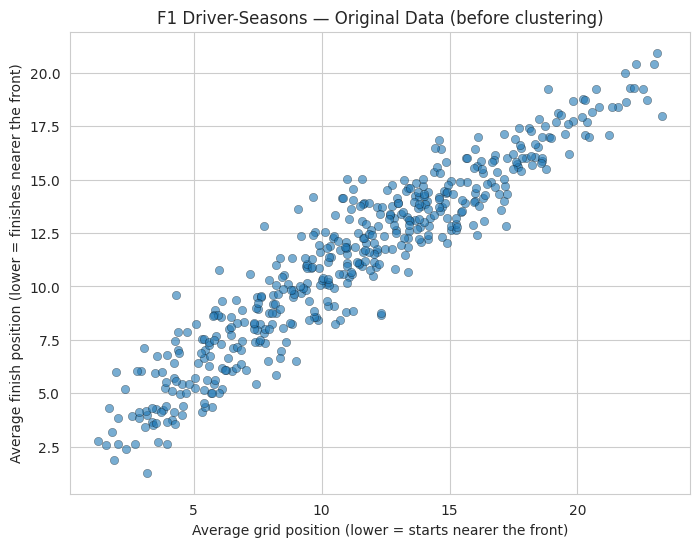

In [14]:
X = df[["avg_grid", "avg_finish"]]

plt.figure(figsize=(8, 6))
plt.scatter(X["avg_grid"], X["avg_finish"], alpha=0.6, edgecolor="k", linewidth=0.3)
plt.xlabel("Average grid position (lower = starts nearer the front)")
plt.ylabel("Average finish position (lower = finishes nearer the front)")
plt.title("F1 Driver-Seasons — Original Data (before clustering)")
plt.grid(True); plt.show()

The points form a clear diagonal band (drivers who start near the front tend to finish near the front), with a spread from the elite corner (bottom-left, low grid + low finish) to the backmarkers (top-right). This spread is exactly the structure K-Means will divide into tiers.

## Step 4 — Feature scaling

K-Means uses **Euclidean distance**, so features on larger scales dominate. Here both features are on a similar 1–24 position scale, but we still standardise them (mean 0, std 1) with `StandardScaler` — this is good practice and the lab lists it as a K-Means requirement.

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("After scaling -> mean:", np.round(X_scaled.mean(axis=0), 2),
      " std:", np.round(X_scaled.std(axis=0), 2))

After scaling -> mean: [-0.  0.]  std: [1. 1.]


## Step 5 — Determine the optimal number of clusters (Elbow Method)

K-Means needs `K` up front. We use the **Elbow Method**: compute WCSS (inertia) for K = 1…10 and look for the "elbow" — the point where adding more clusters stops reducing WCSS much. We also print the **silhouette score** (higher = better-separated clusters) as a second check.

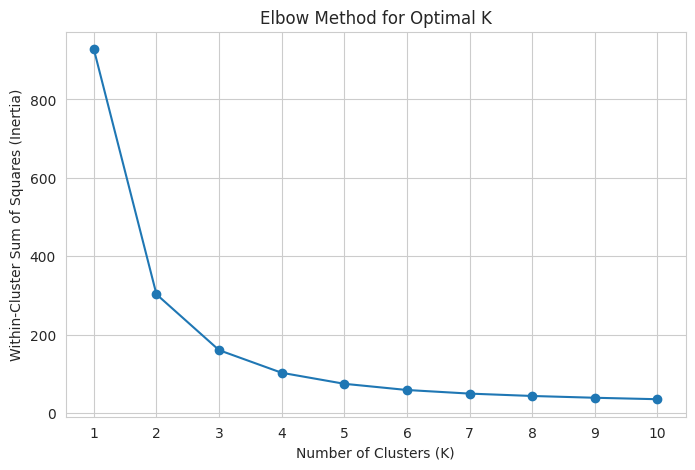

Silhouette scores by K:
  K=2: 0.558
  K=3: 0.503
  K=4: 0.471
  K=5: 0.452
  K=6: 0.427
  K=7: 0.402
  K=8: 0.381
  K=9: 0.361
  K=10: 0.364


In [16]:
inertia, sil = [], []
Ks = range(1, 11)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_) if k > 1 else np.nan)

plt.figure(figsize=(8, 5))
plt.plot(list(Ks), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(Ks)); plt.grid(True); plt.show()

print("Silhouette scores by K:")
for k, s in zip(Ks, sil):
    if k > 1:
        print(f"  K={k}: {s:.3f}")

The curve bends sharply and then flattens around **K = 3–4**. We choose **K = 4** — enough tiers to be meaningful (front-runners, upper-midfield, lower-midfield, backmarkers) while still giving well-separated, compact clusters.

## Step 6 — Apply K-Means clustering

We fit K-Means with `K = 4` and attach the cluster label to each driver-season. `n_init=10` runs the algorithm 10 times from different starts and keeps the best, protecting against a poor random initialisation (a known K-Means limitation).

In [17]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("The Cluster column now holds each driver-season's assigned cluster:")
print(df.head())

The Cluster column now holds each driver-season's assigned cluster:
   driverId     driver_name  season  races  avg_grid  avg_finish  \
0         1  Lewis Hamilton    2007     17  2.588235    3.941176   
1         1  Lewis Hamilton    2008     18  3.888889    5.222222   
2         1  Lewis Hamilton    2009     17  9.176471    9.705882   
3         1  Lewis Hamilton    2010     19  5.157895    6.421053   
4         1  Lewis Hamilton    2011     19  3.578947    6.736842   

   total_points  Cluster  
0         109.0        2  
1          98.0        2  
2          49.0        0  
3         240.0        2  
4         227.0        2  


## Step 7 — Visualize the formed clusters (with centroids)

We plot the driver-seasons coloured by cluster, and mark each cluster's **centroid** (its center) with a large X — exactly like the retail example in the lab. We transform the scaled centroids back to the original position scale so the axes stay interpretable.

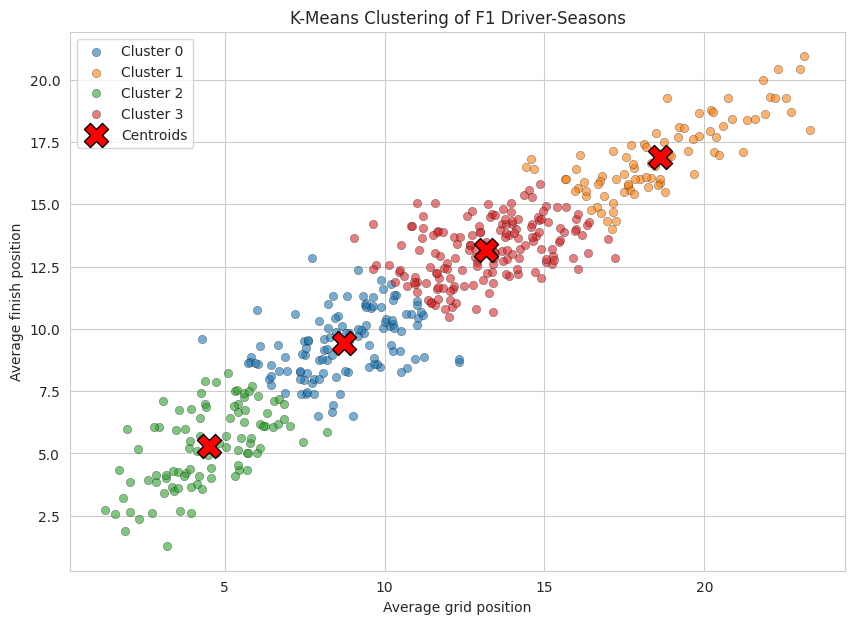

In [18]:
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)   # back to real position units

plt.figure(figsize=(10, 7))
for c in range(K):
    cd = df[df["Cluster"] == c]
    plt.scatter(cd["avg_grid"], cd["avg_finish"], label=f"Cluster {c}", alpha=0.6,
                edgecolor="k", linewidth=0.3)
plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=300, c="red",
            edgecolor="black", label="Centroids")
plt.xlabel("Average grid position")
plt.ylabel("Average finish position")
plt.title("K-Means Clustering of F1 Driver-Seasons")
plt.legend(); plt.grid(True); plt.show()

The four clusters separate cleanly along the diagonal, from the elite bottom-left group to the backmarker top-right group. The red X markers show the average position of each tier.

## Step 8 — Analyze the clusters

We compute the average characteristics of each cluster. Because cluster *numbers* have no inherent meaning, we read the averages to label each cluster as a real performance tier.

In [19]:
cluster_summary = df.groupby("Cluster")[["avg_grid", "avg_finish", "total_points"]].mean().round(2)
cluster_summary["n_driver_seasons"] = df["Cluster"].value_counts().sort_index()
print("Average characteristics of each cluster:")
print(cluster_summary)

Average characteristics of each cluster:
         avg_grid  avg_finish  total_points  n_driver_seasons
Cluster                                                      
0            8.72        9.42         79.04               118
1           18.60       16.92          1.05                85
2            4.50        5.28        230.38                97
3           13.19       13.15         20.21               164


In [20]:
# Auto-label the clusters from best (lowest avg_finish) to worst
order = cluster_summary.sort_values("avg_finish").index.tolist()
tier_names = ["Front-runners / Title contenders",
              "Upper midfield (regular points)",
              "Lower midfield (occasional points)",
              "Backmarkers"]
labels = {cl: name for cl, name in zip(order, tier_names)}
df["Tier"] = df["Cluster"].map(labels)

print("Cluster -> performance tier:")
for cl in order:
    row = cluster_summary.loc[cl]
    print(f"  Cluster {cl}: {labels[cl]:35s} "
          f"(avg grid {row['avg_grid']:.1f}, avg finish {row['avg_finish']:.1f}, "
          f"avg points {row['total_points']:.0f})")

Cluster -> performance tier:
  Cluster 2: Front-runners / Title contenders    (avg grid 4.5, avg finish 5.3, avg points 230)
  Cluster 0: Upper midfield (regular points)     (avg grid 8.7, avg finish 9.4, avg points 79)
  Cluster 3: Lower midfield (occasional points)  (avg grid 13.2, avg finish 13.2, avg points 20)
  Cluster 1: Backmarkers                         (avg grid 18.6, avg finish 16.9, avg points 1)


## Step 9 — Visualize cluster sizes

A bar chart of how many driver-seasons fall in each cluster shows whether the tiers are balanced or whether one group dominates.

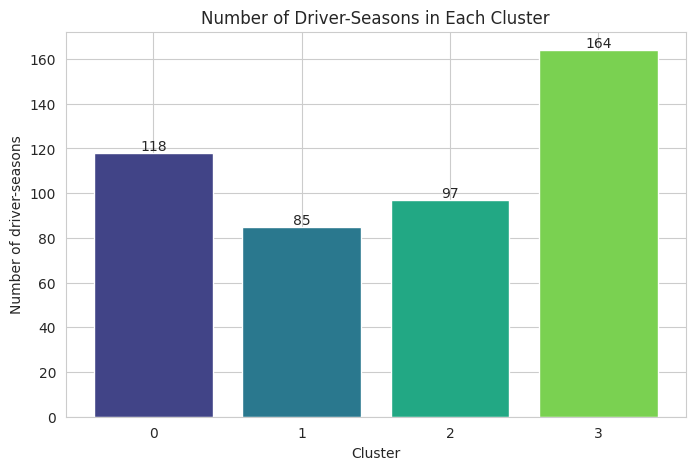

In [21]:
counts = df["Cluster"].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(counts.index.astype(str), counts.values, color=sns.color_palette("viridis", K))
plt.xlabel("Cluster"); plt.ylabel("Number of driver-seasons")
plt.title("Number of Driver-Seasons in Each Cluster")
for i, v in enumerate(counts.values):
    plt.text(i, v + 1, str(v), ha="center")
plt.show()

## Step 10 — Example members of each tier

Finally, we list example driver-seasons in each tier to sanity-check that the groups make intuitive sense (the top tier should contain famous title-winning campaigns).

In [22]:
for cl in order:
    members = df[df["Cluster"] == cl].sort_values("total_points", ascending=False)
    print(f"\n=== {labels[cl]}  (Cluster {cl}, {len(members)} seasons) ===")
    print(members[["driver_name", "season", "avg_grid", "avg_finish", "total_points"]]
          .head(5).to_string(index=False))


=== Front-runners / Title contenders  (Cluster 2, 97 seasons) ===
   driver_name  season  avg_grid  avg_finish  total_points
Max Verstappen    2023  3.181818    1.272727         530.0
Max Verstappen    2022  3.409091    3.500000         433.0
Lewis Hamilton    2019  2.333333    2.380952         413.0
Lewis Hamilton    2018  2.714286    2.619048         408.0
Max Verstappen    2024  3.541667    3.625000         399.0

=== Upper midfield (regular points)  (Cluster 0, 118 seasons) ===
     driver_name  season  avg_grid  avg_finish  total_points
  Lewis Hamilton    2024  8.391304    6.958333         207.0
Daniel Ricciardo    2017  7.368421    8.000000         200.0
  Lewis Hamilton    2012  4.300000    9.600000         190.0
   Jenson Button    2012  6.450000    8.550000         188.0
    Lando Norris    2023  7.954545    8.000000         184.0

=== Lower midfield (occasional points)  (Cluster 3, 164 seasons) ===
       driver_name  season  avg_grid  avg_finish  total_points
Michael Schum